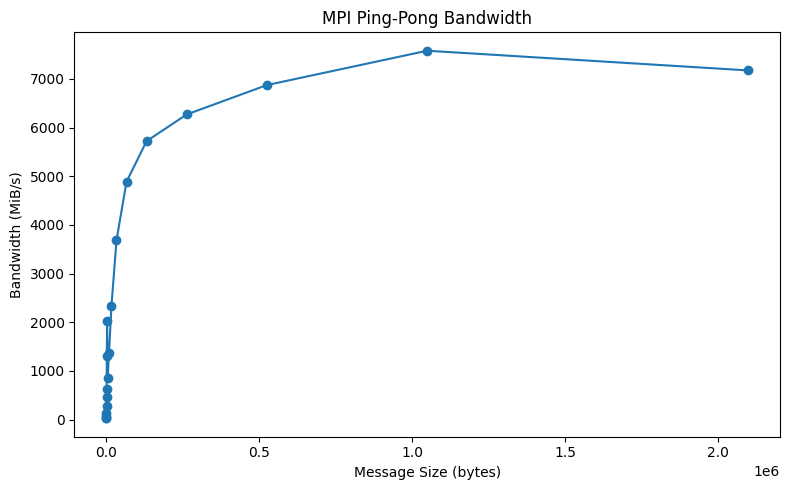

In [1]:
import re
import matplotlib.pyplot as plt

sizes = []
bandwidths = []

with open("bw_results.txt", "r") as f:
    lines = f.readlines()

current_size = None

for line in lines:
    if "Message size" in line:
        current_size = int(re.findall(r"\d+", line)[0])

    if "Bandwidth" in line and current_size is not None:
        bw = float(re.findall(r"[0-9.]+", line)[0])
        sizes.append(current_size)
        bandwidths.append(bw)
        current_size = None

plt.figure(figsize=(8,5))
plt.plot(sizes, bandwidths, marker='o')
#plt.xscale("log", base=2)
plt.xlabel("Message Size (bytes)")
plt.ylabel("Bandwidth (MiB/s)")
plt.title("MPI Ping-Pong Bandwidth")
plt.tight_layout()
plt.savefig("bw_vs_size.png")
plt.show()


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


Latency (c) = 8.16e-06 s
Bandwidth   = 7369.94 MiB/s


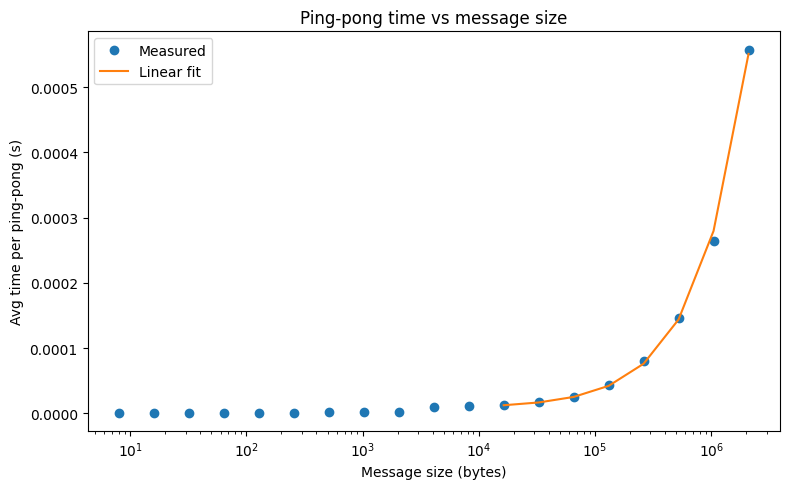

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt

sizes = []
times = []

with open("bw_results.txt") as f:
    lines = f.readlines()

current_size = None

for line in lines:
    if "Message size" in line:
        current_size = int(re.findall(r"\d+", line)[0])

    if "Avg time" in line and current_size is not None:
        t = float(re.findall(r"[0-9.]+", line)[0])
        sizes.append(current_size)
        times.append(t)
        current_size = None

sizes = np.array(sizes)
times = np.array(times)

# Use only large messages for linear fit (>= 16384 bytes)
mask = sizes >= 16384
x = sizes[mask]
y = times[mask]

# Linear fit: y = m x + c
m, c = np.polyfit(x, y, 1)

bandwidth = 2.0 / m / (1024**2)   # MiB/s (factor 2 for ping-pong)

print(f"Latency (c) = {c:.2e} s")
print(f"Bandwidth   = {bandwidth:.2f} MiB/s")

plt.figure(figsize=(8,5))
plt.plot(sizes, times, "o", label="Measured")
plt.plot(x, m*x + c, "-", label="Linear fit")

plt.xscale("log")
plt.xlabel("Message size (bytes)")
plt.ylabel("Avg time per ping-pong (s)")
plt.title("Ping-pong time vs message size")
plt.legend()
plt.tight_layout()
plt.savefig("time_vs_size_fit.png")
plt.show()
